In [119]:
import numpy
import matplotlib.pyplot
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
tf.random.set_seed(1)
from tensorflow import keras
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix
import pandas as pd
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [120]:
##Loading the data from sklearn

breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [121]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [122]:
#Loading the data into a dataframe

data_frame = pd.DataFrame(breast_cancer_dataset.data, columns = breast_cancer_dataset.feature_names)

In [123]:
##Print the first five rows of the dataset

data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [124]:
##Adding target column to the dataframe

data_frame['label'] = breast_cancer_dataset.target


In [125]:
x = data_frame.drop(columns='label', axis =1)
y = data_frame['label']

In [126]:
print(x)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [127]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int64


In [128]:
x_train, x_test, y_train, y_test = train_test_split(x ,y, test_size=0.2, random_state=2)

In [129]:
print (x.shape, x_train.shape, x_test.shape)

(569, 30) (455, 30) (114, 30)


In [130]:
#Standardize the data

from sklearn.preprocessing import StandardScaler

In [131]:
scaler = StandardScaler()

x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)

In [132]:
print(x_train_std)

[[-0.01330339  1.7757658  -0.01491962 ... -0.13236958 -1.08014517
  -0.03527943]
 [-0.8448276  -0.6284278  -0.87702746 ... -1.11552632 -0.85773964
  -0.72098905]
 [ 1.44755936  0.71180168  1.47428816 ...  0.87583964  0.4967602
   0.46321706]
 ...
 [-0.46608541 -1.49375484 -0.53234924 ... -1.32388956 -1.02997851
  -0.75145272]
 [-0.50025764 -1.62161319 -0.527814   ... -0.0987626   0.35796577
  -0.43906159]
 [ 0.96060511  1.21181916  1.00427242 ...  0.8956983  -1.23064515
   0.50697397]]


In [133]:
#Building the neural network

import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [134]:
#Setting up the layers of a neural network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(20, activation="relu"),
    keras.layers.Dense(2, activation='sigmoid')
])

C:\Users\DELL\PycharmProjects\PythonProject\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [135]:
#Compiling the neural network

model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [136]:
 #Training the neural network

history = model.fit(x_train_std, y_train, validation_split=0.1, epochs=11)

Epoch 1/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.4841 - loss: 0.7315 - val_accuracy: 0.5435 - val_loss: 0.6275
Epoch 2/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6993 - loss: 0.5163 - val_accuracy: 0.8478 - val_loss: 0.4401
Epoch 3/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8753 - loss: 0.3743 - val_accuracy: 0.9130 - val_loss: 0.3234
Epoch 4/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9315 - loss: 0.2817 - val_accuracy: 0.9348 - val_loss: 0.2533
Epoch 5/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9487 - loss: 0.2213 - val_accuracy: 0.9348 - val_loss: 0.2087
Epoch 6/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9535 - loss: 0.1816 - val_accuracy: 0.9348 - val_loss: 0.1795
Epoch 7/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9560 - loss: 0.1544 - val_accuracy: 0.9348 - val_loss: 0.1598
Epoch 8/11
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9658 - loss: 0.1353 - val_accuracy: 0.9348 - val_loss

Visualizing the accuracy and loss

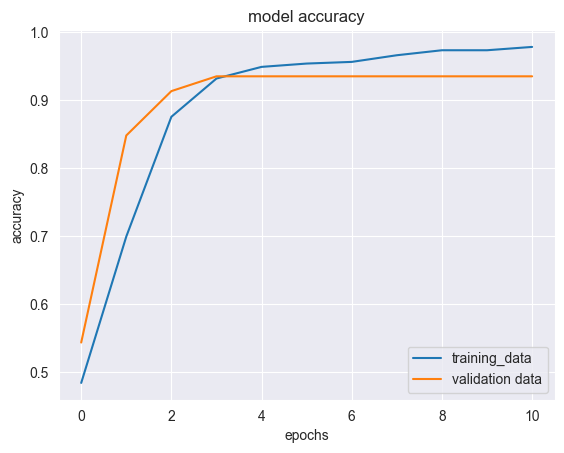

In [137]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')

plt.legend(['training_data', 'validation data'], loc = 'lower right')

In [138]:
#Get the accuracy of the model on test data

loss, accuracy = model.evaluate(x_test_std, y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9825 - loss: 0.1040
0.9824561476707458


In [139]:
#Build a predictive system

print(x_test_std.shape)
print(x_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [140]:
y_pred = model.predict(x_test_std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


In [141]:
print(y_pred.shape)
print(y_pred[0])

(114, 2)
[0.23749578 0.41784412]


In [142]:
#Argmax function

my_list = [10, 20, 30]

index_of_max_value = np.argmax(my_list)
print(my_list)
print(index_of_max_value)

[10, 20, 30]
2


In [143]:
#Converting the prediction probabilities into a class laebl

y_pred_labels = [np.argmax (i) for i in y_pred]
print(y_pred_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

In [144]:
#building the prediction system

#input_data = (17.99,	10.38,	122.8,	1001,	0.1184,	0.2776,	0.3001,	0.1471,	0.2419,	0.07871,	1.095,	0.9053,	8.589,	153.4,	0.006399,	0.04904,	0.05373,	0.01587,	0.03003,	0.006193,	25.38,	17.33,	184.6,	2019,	0.1622,	0.6656,	0.7119,	0.2654,	0.4601,	0.1189,)

input_data = (13.54,	14.36,	87.46,	566.3,	0.09779,	0.08129,	0.06664,	0.04781,	0.1885,	0.05766,	0.2699,	0.7886,	2.058,	23.56,	0.008462,	0.0146,	0.02387,	0.01315,	0.0198,	0.0023,	15.11,	19.26,	99.7,	711.2,	0.144,	0.1773,	0.239,	0.1288,	0.2977,	0.07259)

#Change the input data to a numpy array

input_data_as_numpy_array = np.asarray(input_data)

#reshape the numpy array  as we arw predicting for one data point

input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

#Standardizing the input data

input_data_std = scaler.transform(input_data_reshaped)

prediction = model.predict(input_data_std)

print(prediction)

prediction_label = [np.argmax(prediction)]

print (prediction_label)

if (prediction_label[0] == 0):
    print("The tumor is malignant")

else:
    print("The tumor is benign")

C:\Users\DELL\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
[[0.2708283 0.7222867]]
[np.int64(1)]
The tumor is benign
